## End-to-End: Data → EDA → Features → Models → Deployment

**Goal:** Predict hypoglycemia (glucose < 70 mg/dL) 30 minutes in advance

**Dataset:** HUPA-UCM diabetes dataset with 17 patients


## 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Try to import XGBoost and LightGBM (optional)
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 8)
np.random.seed(42)

print("Core libraries loaded successfully")
print(f"   XGBoost available: {XGBOOST_AVAILABLE}")
print(f"   LightGBM available: {LIGHTGBM_AVAILABLE}")

Core libraries loaded successfully
   XGBoost available: True
   LightGBM available: True


In [4]:
# Configuration
DATA_DIRECTORY = "diabetes_data"  
OUTPUT_DIRECTORY = "outputs"
MODEL_SAVE_PATH = "final_model.pkl"

# Prediction settings
PREDICTION_HORIZON_MINUTES = 30
HYPOGLYCEMIA_THRESHOLD = 70
PREDICTION_STEPS = PREDICTION_HORIZON_MINUTES // 5

# Create output directory
Path(OUTPUT_DIRECTORY).mkdir(exist_ok=True)

print(f"Configuration:")
print(f"   Data directory: {DATA_DIRECTORY}")
print(f"   Prediction horizon: {PREDICTION_HORIZON_MINUTES} minutes")
print(f"   Hypoglycemia threshold: {HYPOGLYCEMIA_THRESHOLD} mg/dL")

Configuration:
   Data directory: diabetes_data
   Prediction horizon: 30 minutes
   Hypoglycemia threshold: 70 mg/dL


## 2. Data Loading and Validation

In [5]:
def load_patient_file(file_path):
    patient_id = file_path.stem
    df = pd.read_csv(file_path, sep=';')
    df['time'] = pd.to_datetime(df['time'])
    df['patient_id'] = patient_id
    df = df.sort_values('time').reset_index(drop=True)
    return df

data_path = Path(DATA_DIRECTORY)

if not data_path.exists():
    print(f"Error: Data directory '{DATA_DIRECTORY}' not found!")
    print(f"   Current directory: {Path.cwd()}")
    print(f"   Please update DATA_DIRECTORY in the cell above.")
else:
    csv_files = sorted(list(data_path.glob("*.csv")))
    
    if len(csv_files) == 0:
        print(f"No CSV files found in '{DATA_DIRECTORY}'")
    else:
        print(f"Found {len(csv_files)} patient files")
        print("\nLoading patient data...")
        
        all_patients = []
        for i, file in enumerate(csv_files, 1):
            patient_df = load_patient_file(file)
            all_patients.append(patient_df)
            print(f"  [{i}/{len(csv_files)}] {file.name}: {len(patient_df):,} records")
        
        df = pd.concat(all_patients, ignore_index=True)
        
        print(f"\nSuccessfully loaded {len(df):,} total records")
        print(f"   Patients: {df['patient_id'].nunique()}")
        print(f"   Date range: {df['time'].min()} to {df['time'].max()}")
        print(f"   Duration: {(df['time'].max() - df['time'].min()).days} days")

Found 25 patient files

Loading patient data...
  [1/25] HUPA0001P.csv: 4,096 records
  [2/25] HUPA0002P.csv: 3,181 records
  [3/25] HUPA0003P.csv: 3,770 records
  [4/25] HUPA0004P.csv: 3,184 records
  [5/25] HUPA0005P.csv: 3,858 records
  [6/25] HUPA0006P.csv: 2,290 records
  [7/25] HUPA0007P.csv: 3,857 records
  [8/25] HUPA0009P.csv: 3,812 records
  [9/25] HUPA0010P.csv: 2,976 records
  [10/25] HUPA0011P.csv: 3,839 records
  [11/25] HUPA0014P.csv: 3,829 records
  [12/25] HUPA0015P.csv: 3,792 records
  [13/25] HUPA0016P.csv: 3,835 records
  [14/25] HUPA0017P.csv: 3,599 records
  [15/25] HUPA0018P.csv: 3,895 records
  [16/25] HUPA0019P.csv: 3,711 records
  [17/25] HUPA0020P.csv: 2,862 records
  [18/25] HUPA0021P.csv: 2,343 records
  [19/25] HUPA0022P.csv: 4,023 records
  [20/25] HUPA0023P.csv: 3,919 records
  [21/25] HUPA0024P.csv: 2,902 records
  [22/25] HUPA0025P.csv: 4,006 records
  [23/25] HUPA0026P.csv: 40,605 records
  [24/25] HUPA0027P.csv: 165,306 records
  [25/25] HUPA0028P.cs

In [6]:
# Data structure inspection
print("Dataset Structure:")
print(f"   Shape: {df.shape}")
print(f"\n   Columns ({len(df.columns)}):")
for col in df.columns:
    print(f"      - {col}")

print("\nFirst 5 rows:")
df.head()

Dataset Structure:
   Shape: (309392, 9)

   Columns (9):
      - time
      - glucose
      - calories
      - heart_rate
      - steps
      - basal_rate
      - bolus_volume_delivered
      - carb_input
      - patient_id

First 5 rows:


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13 18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13 18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13 18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13 18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13 19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


In [7]:
# Data quality checks
print("Data Quality Checks:")

print("\n1. Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing'] > 0])

print("\n2. Glucose statistics:")
print(f"   Min: {df['glucose'].min():.1f} mg/dL")
print(f"   Max: {df['glucose'].max():.1f} mg/dL")
print(f"   Mean: {df['glucose'].mean():.1f} mg/dL")
print(f"   Median: {df['glucose'].median():.1f} mg/dL")
print(f"   Std: {df['glucose'].std():.1f} mg/dL")

print("\n3. Glucose ranges:")
print(f"   Hypoglycemia (<70): {(df['glucose'] < 70).sum():,} ({(df['glucose'] < 70).mean()*100:.2f}%)")
print(f"   Normal (70-180): {((df['glucose'] >= 70) & (df['glucose'] <= 180)).sum():,} ({((df['glucose'] >= 70) & (df['glucose'] <= 180)).mean()*100:.2f}%)")
print(f"   Hyperglycemia (>180): {(df['glucose'] > 180).sum():,} ({(df['glucose'] > 180).mean()*100:.2f}%)")

Data Quality Checks:

1. Missing values:
Empty DataFrame
Columns: [Missing, Percentage]
Index: []

2. Glucose statistics:
   Min: 40.0 mg/dL
   Max: 444.0 mg/dL
   Mean: 141.4 mg/dL
   Median: 132.0 mg/dL
   Std: 57.1 mg/dL

3. Glucose ranges:
   Hypoglycemia (<70): 20,377 (6.59%)
   Normal (70-180): 221,892 (71.72%)
   Hyperglycemia (>180): 67,123 (21.70%)


## 3. Comprehensive Exploratory Data Analysis

### 3.1 Clinical Glycemic Metrics

In [9]:
def calculate_clinical_metrics(patient_data):
    glucose = patient_data['glucose'].dropna()
    
    metrics = {}
    metrics['mean_glucose'] = glucose.mean()
    metrics['std_glucose'] = glucose.std()
    metrics['cv_percent'] = (metrics['std_glucose'] / metrics['mean_glucose'] * 100)
    metrics['gmi_percent'] = 3.31 + (0.02392 * metrics['mean_glucose'])
    
    metrics['tbr_level2'] = (glucose < 54).sum() / len(glucose) * 100
    metrics['tbr_level1'] = ((glucose >= 54) & (glucose < 70)).sum() / len(glucose) * 100
    metrics['tbr_total'] = (glucose < 70).sum() / len(glucose) * 100
    
    metrics['tir'] = ((glucose >= 70) & (glucose <= 180)).sum() / len(glucose) * 100
    
    metrics['tar_level1'] = ((glucose > 180) & (glucose <= 250)).sum() / len(glucose) * 100
    metrics['tar_level2'] = (glucose > 250).sum() / len(glucose) * 100
    metrics['tar_total'] = (glucose > 180).sum() / len(glucose) * 100
    
    return metrics

print("Calculating clinical metrics for each patient...")

clinical_results = []
for patient_id in df['patient_id'].unique():
    patient_data = df[df['patient_id'] == patient_id]
    metrics = calculate_clinical_metrics(patient_data)
    metrics['patient_id'] = patient_id
    clinical_results.append(metrics)

clinical_df = pd.DataFrame(clinical_results)
clinical_df = clinical_df[[
    'patient_id', 'mean_glucose', 'std_glucose', 'cv_percent', 'gmi_percent',
    'tbr_total', 'tir', 'tar_total'
]].round(2)

print("\nClinical Metrics Summary:")
clinical_df

Calculating clinical metrics for each patient...

Clinical Metrics Summary:


,patient_id,mean_glucose,std_glucose,cv_percent,gmi_percent,tbr_total,tir,tar_total
0,HUPA0001P,181.44,70.64,38.93,7.65,1.44,56.49,42.07
1,HUPA0002P,113.47,59.15,52.12,6.02,23.86,61.49,14.65
2,HUPA0003P,143.27,61.33,42.80,6.74,7.03,67.67,25.31
3,HUPA0004P,180.38,83.02,46.03,7.62,9.70,44.82,45.48
4,HUPA0005P,147.70,49.79,33.71,6.84,2.95,71.82,25.22
5,HUPA0006P,165.20,84.74,51.29,7.26,8.65,56.03,35.33
6,HUPA0007P,173.15,78.66,45.43,7.45,8.94,45.86,45.19
7,HUPA0009P,193.74,46.11,23.80,7.94,0.00,41.45,58.55
8,HUPA0010P,135.89,57.61,42.39,6.56,8.33,74.83,16.83
9,HUPA0011P,159.11,57.09,35.88,7.12,2.68,65.07,32.25


In [10]:
# Clinical targets
print("\nClinical Goals vs Actual Performance:")
print("\n1. Time in Range (TIR):")
print(f"   Goal: >70%")
print(f"   Actual: {clinical_df['tir'].mean():.1f}% (avg)")
print(f"   Range: {clinical_df['tir'].min():.1f}% - {clinical_df['tir'].max():.1f}%")
print(f"   Patients meeting goal: {(clinical_df['tir'] > 70).sum()}/{len(clinical_df)}")

print("\n2. Time Below Range (TBR):")
print(f"   Goal: <4%")
print(f"   Actual: {clinical_df['tbr_total'].mean():.1f}% (avg)")
print(f"   Range: {clinical_df['tbr_total'].min():.1f}% - {clinical_df['tbr_total'].max():.1f}%")
print(f"   Patients meeting goal: {(clinical_df['tbr_total'] < 4).sum()}/{len(clinical_df)}")

print("\n3. Coefficient of Variation (CV):")
print(f"   Goal: <36% (stable glucose)")
print(f"   Actual: {clinical_df['cv_percent'].mean():.1f}% (avg)")
print(f"   Range: {clinical_df['cv_percent'].min():.1f}% - {clinical_df['cv_percent'].max():.1f}%")
print(f"   Patients meeting goal: {(clinical_df['cv_percent'] < 36).sum()}/{len(clinical_df)}")

print("\n4. Glucose Management Indicator (GMI):")
print(f"   Goal: <7% (good long-term control)")
print(f"   Actual: {clinical_df['gmi_percent'].mean():.1f}% (avg)")
print(f"   Range: {clinical_df['gmi_percent'].min():.1f}% - {clinical_df['gmi_percent'].max():.1f}%")
print(f"   Patients meeting goal: {(clinical_df['gmi_percent'] < 7).sum()}/{len(clinical_df)}")


Clinical Goals vs Actual Performance:

1. Time in Range (TIR):
   Goal: >70%
   Actual: 60.7% (avg)
   Range: 35.7% - 88.8%
   Patients meeting goal: 8/25

2. Time Below Range (TBR):
   Goal: <4%
   Actual: 7.4% (avg)
   Range: 0.0% - 23.9%
   Patients meeting goal: 8/25

3. Coefficient of Variation (CV):
   Goal: <36% (stable glucose)
   Actual: 39.6% (avg)
   Range: 23.8% - 53.1%
   Patients meeting goal: 10/25

4. Glucose Management Indicator (GMI):
   Goal: <7% (good long-term control)
   Actual: 7.0% (avg)
   Range: 6.0% - 8.1%
   Patients meeting goal: 12/25


### 3.2 Visualizations

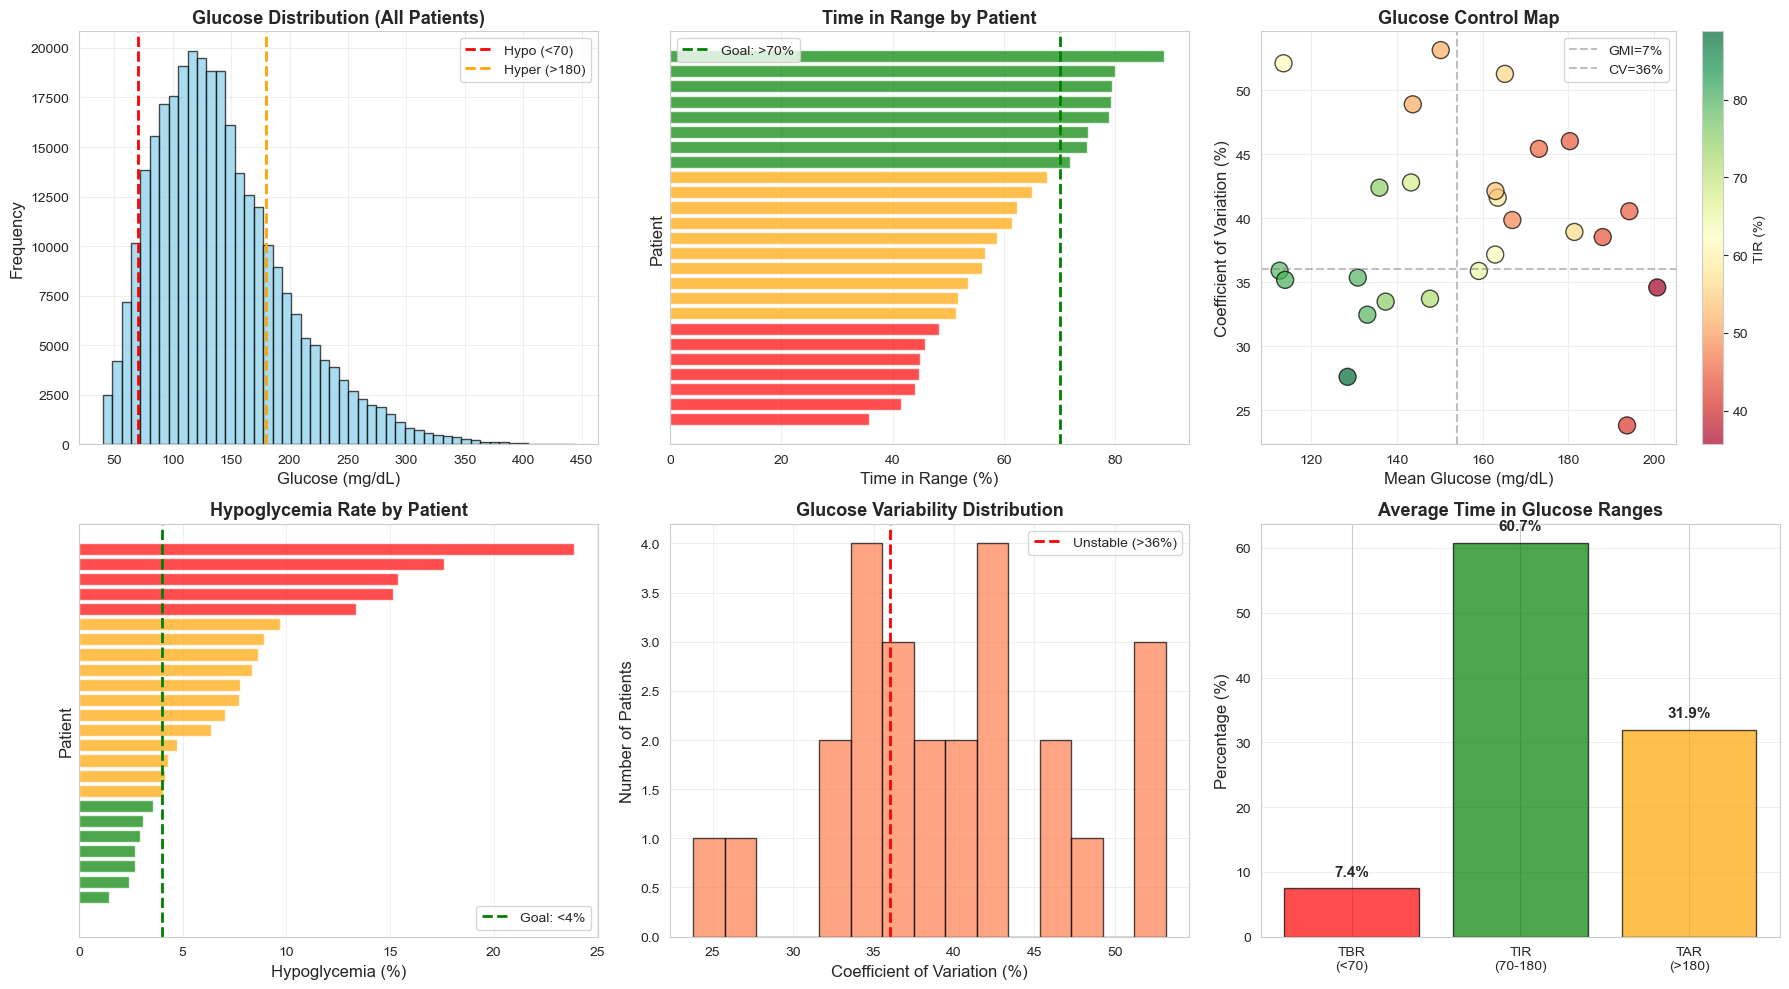

Saved: clinical_eda.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Glucose distribution
axes[0, 0].hist(df['glucose'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(70, color='red', linestyle='--', linewidth=2, label='Hypo (<70)')
axes[0, 0].axvline(180, color='orange', linestyle='--', linewidth=2, label='Hyper (>180)')
axes[0, 0].set_xlabel('Glucose (mg/dL)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Glucose Distribution (All Patients)', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. TIR by patient
clinical_sorted = clinical_df.sort_values('tir', ascending=True)
colors = ['green' if x > 70 else 'orange' if x > 50 else 'red' for x in clinical_sorted['tir']]
axes[0, 1].barh(range(len(clinical_sorted)), clinical_sorted['tir'], color=colors, alpha=0.7)
axes[0, 1].axvline(70, color='green', linestyle='--', linewidth=2, label='Goal: >70%')
axes[0, 1].set_xlabel('Time in Range (%)', fontsize=12)
axes[0, 1].set_ylabel('Patient', fontsize=12)
axes[0, 1].set_title('Time in Range by Patient', fontweight='bold', fontsize=13)
axes[0, 1].set_yticks([])
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. Mean glucose vs CV
scatter = axes[0, 2].scatter(
    clinical_df['mean_glucose'], 
    clinical_df['cv_percent'],
    c=clinical_df['tir'],
    s=150,
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black'
)
axes[0, 2].axvline(154, color='gray', linestyle='--', alpha=0.5, label='GMI=7%')
axes[0, 2].axhline(36, color='gray', linestyle='--', alpha=0.5, label='CV=36%')
axes[0, 2].set_xlabel('Mean Glucose (mg/dL)', fontsize=12)
axes[0, 2].set_ylabel('Coefficient of Variation (%)', fontsize=12)
axes[0, 2].set_title('Glucose Control Map', fontweight='bold', fontsize=13)
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 2], label='TIR (%)')

# 4. Hypoglycemia rate
hypo_pct = df.groupby('patient_id').apply(
    lambda x: (x['glucose'] < 70).sum() / len(x) * 100
).sort_values()
colors_hypo = ['green' if x < 4 else 'orange' if x < 10 else 'red' for x in hypo_pct]
axes[1, 0].barh(range(len(hypo_pct)), hypo_pct.values, color=colors_hypo, alpha=0.7)
axes[1, 0].axvline(4, color='green', linestyle='--', linewidth=2, label='Goal: <4%')
axes[1, 0].set_xlabel('Hypoglycemia (%)', fontsize=12)
axes[1, 0].set_ylabel('Patient', fontsize=12)
axes[1, 0].set_title('Hypoglycemia Rate by Patient', fontweight='bold', fontsize=13)
axes[1, 0].set_yticks([])
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='x')

# 5. CV distribution
axes[1, 1].hist(clinical_df['cv_percent'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].axvline(36, color='red', linestyle='--', linewidth=2, label='Unstable (>36%)')
axes[1, 1].set_xlabel('Coefficient of Variation (%)', fontsize=12)
axes[1, 1].set_ylabel('Number of Patients', fontsize=12)
axes[1, 1].set_title('Glucose Variability Distribution', fontweight='bold', fontsize=13)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. TBR/TIR/TAR breakdown
categories = ['TBR\n(<70)', 'TIR\n(70-180)', 'TAR\n(>180)']
values = [
    clinical_df['tbr_total'].mean(),
    clinical_df['tir'].mean(),
    clinical_df['tar_total'].mean()
]
colors_ranges = ['red', 'green', 'orange']
axes[1, 2].bar(categories, values, color=colors_ranges, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 2].set_title('Average Time in Glucose Ranges', fontweight='bold', fontsize=13)
axes[1, 2].grid(alpha=0.3, axis='y')
for i, v in enumerate(values):
    axes[1, 2].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIRECTORY}/clinical_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: clinical_eda.png")

### 3.3 Feature Correlation Analysis

In [12]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'patient_id']

print(f"Analyzing correlations for {len(numeric_cols)} numeric features:")
print(f"   {numeric_cols}")

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Display correlation with glucose
glucose_corr = correlation_matrix['glucose'].sort_values(ascending=False)
print("\n Correlation with Glucose:")
print(glucose_corr)

Analyzing correlations for 7 numeric features:
   ['glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input']

 Correlation with Glucose:
glucose                   1.000000
heart_rate                0.098367
steps                     0.051278
bolus_volume_delivered    0.020125
calories                  0.008556
carb_input               -0.001038
basal_rate               -0.022566
Name: glucose, dtype: float64


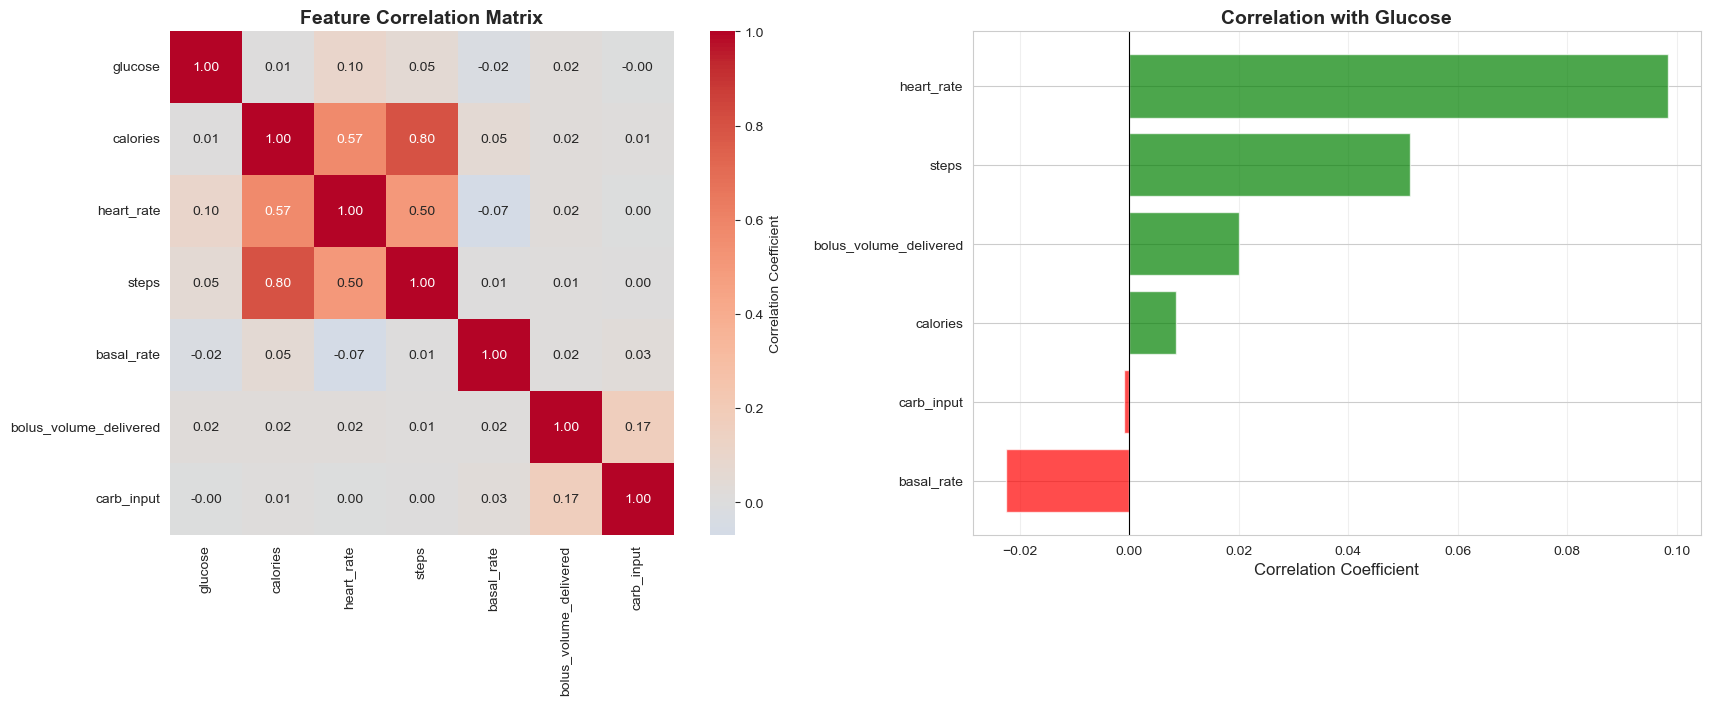

Saved: feature_correlation.png


In [13]:
# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=axes[0],
    cbar_kws={'label': 'Correlation Coefficient'}
)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

# Correlation with glucose (bar plot)
glucose_corr_sorted = glucose_corr.drop('glucose').sort_values()
colors_corr = ['red' if x < 0 else 'green' for x in glucose_corr_sorted]
axes[1].barh(range(len(glucose_corr_sorted)), glucose_corr_sorted.values, color=colors_corr, alpha=0.7)
axes[1].set_yticks(range(len(glucose_corr_sorted)))
axes[1].set_yticklabels(glucose_corr_sorted.index)
axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
axes[1].set_title('Correlation with Glucose', fontweight='bold', fontsize=14)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIRECTORY}/feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: feature_correlation.png")

In [14]:
# Statistical significance of correlations
from scipy.stats import pearsonr

print("\nStatistical Significance of Correlations with Glucose:")

print(f"{'Feature':<25} {'Correlation':>12} {'P-value':>12} {'Significant':>12}")


for feature in numeric_cols:
    if feature != 'glucose':
        valid_mask = df[[feature, 'glucose']].notna().all(axis=1)
        if valid_mask.sum() > 2:
            corr, pval = pearsonr(
                df.loc[valid_mask, feature],
                df.loc[valid_mask, 'glucose']
            )
            sig = '✓ Yes' if pval < 0.05 else '✗ No'
            print(f"{feature:<25} {corr:>12.4f} {pval:>12.4e} {sig:>12}")


print("\nNote: P-value < 0.05 indicates statistically significant correlation")


Statistical Significance of Correlations with Glucose:
Feature                    Correlation      P-value  Significant
calories                        0.0086   1.9462e-06        ✓ Yes
heart_rate                      0.0984   0.0000e+00        ✓ Yes
steps                           0.0513  3.6033e-179        ✓ Yes
basal_rate                     -0.0226   3.8042e-36        ✓ Yes
bolus_volume_delivered          0.0201   4.3042e-29        ✓ Yes
carb_input                     -0.0010   5.6355e-01         ✗ No

Note: P-value < 0.05 indicates statistically significant correlation


### 3.4 Time-Based Patterns

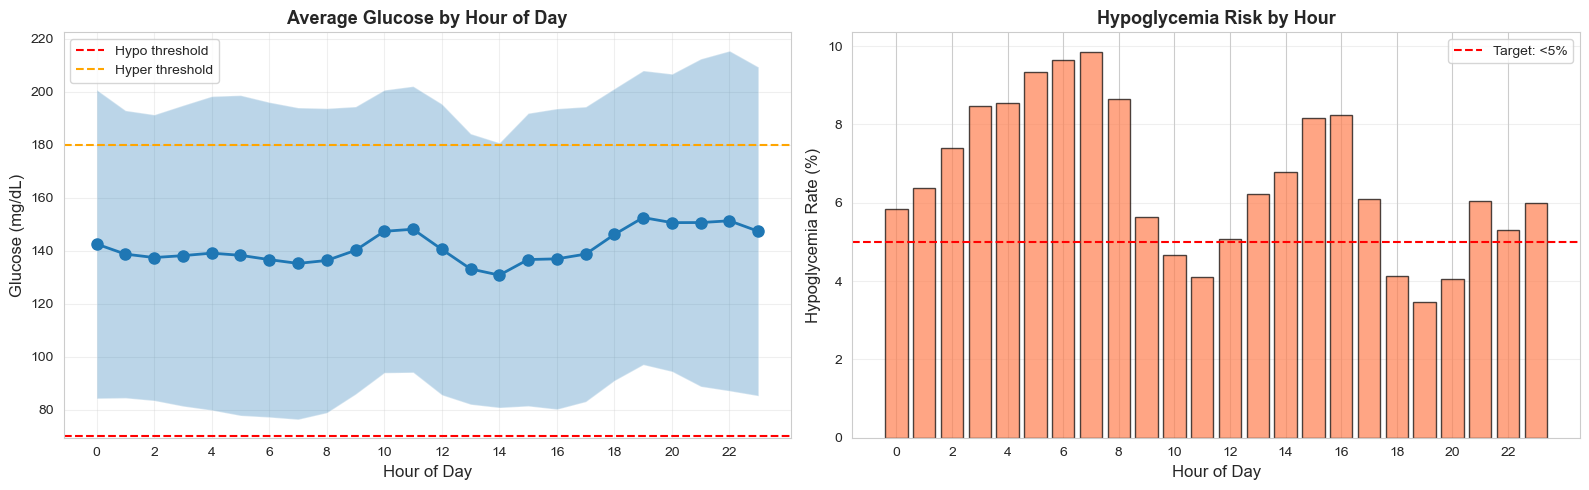


Key Time Patterns:
   Highest risk hour: 7:00 (9.86%)
   Lowest risk hour: 19:00 (3.46%)
   Overnight risk (0-6 AM): 7.66%


In [15]:
# Extract time features
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek

# Average glucose by hour
hourly_glucose = df.groupby('hour')['glucose'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Glucose by hour of day
axes[0].plot(hourly_glucose.index, hourly_glucose['mean'], marker='o', linewidth=2, markersize=8)
axes[0].fill_between(
    hourly_glucose.index,
    hourly_glucose['mean'] - hourly_glucose['std'],
    hourly_glucose['mean'] + hourly_glucose['std'],
    alpha=0.3
)
axes[0].axhline(70, color='red', linestyle='--', label='Hypo threshold')
axes[0].axhline(180, color='orange', linestyle='--', label='Hyper threshold')
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Glucose (mg/dL)', fontsize=12)
axes[0].set_title('Average Glucose by Hour of Day', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Hypoglycemia rate by hour
hypo_by_hour = df.groupby('hour').apply(
    lambda x: (x['glucose'] < 70).sum() / len(x) * 100
)
axes[1].bar(hypo_by_hour.index, hypo_by_hour.values, alpha=0.7, color='coral', edgecolor='black')
axes[1].axhline(5, color='red', linestyle='--', label='Target: <5%')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Hypoglycemia Rate (%)', fontsize=12)
axes[1].set_title('Hypoglycemia Risk by Hour', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIRECTORY}/time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


print("\nKey Time Patterns:")
print(f"   Highest risk hour: {hypo_by_hour.idxmax()}:00 ({hypo_by_hour.max():.2f}%)")
print(f"   Lowest risk hour: {hypo_by_hour.idxmin()}:00 ({hypo_by_hour.min():.2f}%)")
print(f"   Overnight risk (0-6 AM): {hypo_by_hour[0:6].mean():.2f}%")

## 4. Train/Test Split by Patient

In [16]:
patients = df['patient_id'].unique()
n_patients = len(patients)

np.random.shuffle(patients)

n_train = int(n_patients * 0.6)
n_val = int(n_patients * 0.2)
n_test = n_patients - n_train - n_val

train_patients = patients[:n_train]
val_patients = patients[n_train:n_train+n_val]
test_patients = patients[n_train+n_val:]

print(f"Patient Split:")
print(f"   Total patients: {n_patients}")
print(f"   Training: {n_train} patients ({n_train/n_patients*100:.1f}%)")
print(f"   Validation: {n_val} patients ({n_val/n_patients*100:.1f}%)")
print(f"   Test: {n_test} patients ({n_test/n_patients*100:.1f}%)")

print(f"\n   Training patients: {sorted(train_patients)}")
print(f"   Validation patients: {sorted(val_patients)}")
print(f"   Test patients: {sorted(test_patients)}")

train_mask = df['patient_id'].isin(train_patients)
val_mask = df['patient_id'].isin(val_patients)
test_mask = df['patient_id'].isin(test_patients)

train_df = df[train_mask].reset_index(drop=True)
val_df = df[val_mask].reset_index(drop=True)
test_df = df[test_mask].reset_index(drop=True)

print(f"\nData Split:")
print(f"   Training: {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test: {len(test_df):,} samples")

# Verify no overlap
overlap = set(train_patients) & set(val_patients) & set(test_patients)
if len(overlap) == 0:
    print(f"\nNo patient overlap - data split is valid!")
else:
    print(f"\nWARNING: Patient overlap detected: {overlap}")

Patient Split:
   Total patients: 25
   Training: 15 patients (60.0%)
   Validation: 5 patients (20.0%)
   Test: 5 patients (20.0%)

   Training patients: ['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P', 'HUPA0006P', 'HUPA0010P', 'HUPA0011P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0019P', 'HUPA0020P', 'HUPA0026P', 'HUPA0027P']
   Validation patients: ['HUPA0021P', 'HUPA0022P', 'HUPA0024P', 'HUPA0025P', 'HUPA0028P']
   Test patients: ['HUPA0007P', 'HUPA0009P', 'HUPA0014P', 'HUPA0018P', 'HUPA0023P']

Data Split:
   Training: 250,904 samples
   Validation: 39,176 samples
   Test: 19,312 samples

No patient overlap - data split is valid!


## 5. Feature Engineering

Creating 60+ features from raw data

In [17]:
def add_temporal_features(df):
    df = df.copy()
    df['hour'] = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.dayofweek
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['minutes_since_midnight'] = df['hour'] * 60 + df['time'].dt.minute
    return df

train_df = add_temporal_features(train_df)
val_df = add_temporal_features(val_df)
test_df = add_temporal_features(test_df)

print("Temporal features added (6 features)")

Temporal features added (6 features)


In [18]:
def add_glucose_features(df):
    all_patients = []
    
    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].copy()
        
        patient_df['glucose_velocity'] = patient_df['glucose'].diff() / 5
        patient_df['glucose_acceleration'] = patient_df['glucose_velocity'].diff()
        
        for window in [3, 6, 12]:
            window_min = window * 5
            patient_df[f'glucose_mean_{window_min}min'] = (
                patient_df['glucose'].rolling(window=window, min_periods=1).mean()
            )
            patient_df[f'glucose_std_{window_min}min'] = (
                patient_df['glucose'].rolling(window=window, min_periods=1).std()
            )
            patient_df[f'glucose_min_{window_min}min'] = (
                patient_df['glucose'].rolling(window=window, min_periods=1).min()
            )
            patient_df[f'glucose_max_{window_min}min'] = (
                patient_df['glucose'].rolling(window=window, min_periods=1).max()
            )
        
        all_patients.append(patient_df)
    
    return pd.concat(all_patients, ignore_index=True)

print("Engineering glucose features")
train_df = add_glucose_features(train_df)
val_df = add_glucose_features(val_df)
test_df = add_glucose_features(test_df)


Engineering glucose features


In [19]:
def add_insulin_carb_features(df):
    all_patients = []
    
    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].copy()
        
        for window in [3, 6, 12]:
            window_min = window * 5
            
            patient_df[f'bolus_sum_{window_min}min'] = (
                patient_df['bolus_volume_delivered'].rolling(window=window, min_periods=1).sum()
            )
            patient_df[f'basal_sum_{window_min}min'] = (
                patient_df['basal_rate'].rolling(window=window, min_periods=1).sum()
            )
            patient_df[f'carb_sum_{window_min}min'] = (
                patient_df['carb_input'].rolling(window=window, min_periods=1).sum()
            )
        
        patient_df['insulin_on_board'] = (
            patient_df['bolus_volume_delivered'].rolling(window=48, min_periods=1).sum()
        )
        
        patient_df['carb_to_insulin_ratio'] = (
            patient_df['carb_sum_60min'] / (patient_df['bolus_sum_60min'] + 0.1)
        )
        
        all_patients.append(patient_df)
    
    return pd.concat(all_patients, ignore_index=True)

print("Engineering insulin and carb features")
train_df = add_insulin_carb_features(train_df)
val_df = add_insulin_carb_features(val_df)
test_df = add_insulin_carb_features(test_df)

Engineering insulin and carb features


In [20]:
def add_activity_features(df):
    all_patients = []
    
    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].copy()
        
        for window in [3, 6, 12]:
            window_min = window * 5
            
            patient_df[f'steps_sum_{window_min}min'] = (
                patient_df['steps'].rolling(window=window, min_periods=1).sum()
            )
            patient_df[f'calories_sum_{window_min}min'] = (
                patient_df['calories'].rolling(window=window, min_periods=1).sum()
            )
            patient_df[f'heart_rate_mean_{window_min}min'] = (
                patient_df['heart_rate'].rolling(window=window, min_periods=1).mean()
            )
        
        all_patients.append(patient_df)
    
    return pd.concat(all_patients, ignore_index=True)

print("Engineering activity features.")
train_df = add_activity_features(train_df)
val_df = add_activity_features(val_df)
test_df = add_activity_features(test_df)


Engineering activity features.


In [21]:
def create_target(df, prediction_steps, threshold):
    all_patients = []
    
    for patient_id in df['patient_id'].unique():
        patient_df = df[df['patient_id'] == patient_id].copy()
        future_glucose = patient_df['glucose'].shift(-prediction_steps)
        patient_df['target'] = (future_glucose < threshold).astype(int)
        patient_df['future_glucose'] = future_glucose
        all_patients.append(patient_df)
    
    result = pd.concat(all_patients, ignore_index=True)
    return result[result['future_glucose'].notna()].copy()

print(f"Creating target variable (hypoglycemia in {PREDICTION_HORIZON_MINUTES} min)...")
train_df = create_target(train_df, PREDICTION_STEPS, HYPOGLYCEMIA_THRESHOLD)
val_df = create_target(val_df, PREDICTION_STEPS, HYPOGLYCEMIA_THRESHOLD)
test_df = create_target(test_df, PREDICTION_STEPS, HYPOGLYCEMIA_THRESHOLD)

print(f"\nTarget variable created")
print(f"   Training: {train_df['target'].sum():,} hypo events ({train_df['target'].mean()*100:.2f}%)")
print(f"   Validation: {val_df['target'].sum():,} hypo events ({val_df['target'].mean()*100:.2f}%)")
print(f"   Test: {test_df['target'].sum():,} hypo events ({test_df['target'].mean()*100:.2f}%)")

Creating target variable (hypoglycemia in 30 min)...

Target variable created
   Training: 16,719 hypo events (6.67%)
   Validation: 2,283 hypo events (5.83%)
   Test: 1,347 hypo events (6.99%)


In [22]:
# Prepare feature matrix
exclude_cols = [
    'time', 'patient_id', 'target', 'future_glucose',
    'glucose', 'hour', 'day_of_week'
]

feature_cols = [col for col in train_df.columns if col not in exclude_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df['target'].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df['target'].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df['target'].copy()

# Handle missing values
X_train = X_train.fillna(method='ffill').fillna(0)
X_val = X_val.fillna(method='ffill').fillna(0)
X_test = X_test.fillna(method='ffill').fillna(0)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"   Number of features: {len(feature_cols)}")
print(f"   X_train shape: {X_train_scaled.shape}")
print(f"   X_val shape: {X_val_scaled.shape}")
print(f"   X_test shape: {X_test_scaled.shape}")

print(f"\nFeature List:")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

   Number of features: 44
   X_train shape: (250814, 44)
   X_val shape: (39146, 44)
   X_test shape: (19282, 44)

Feature List:
    1. calories
    2. heart_rate
    3. steps
    4. basal_rate
    5. bolus_volume_delivered
    6. carb_input
    7. hour_sin
    8. hour_cos
    9. is_weekend
   10. minutes_since_midnight
   11. glucose_velocity
   12. glucose_acceleration
   13. glucose_mean_15min
   14. glucose_std_15min
   15. glucose_min_15min
   16. glucose_max_15min
   17. glucose_mean_30min
   18. glucose_std_30min
   19. glucose_min_30min
   20. glucose_max_30min
   21. glucose_mean_60min
   22. glucose_std_60min
   23. glucose_min_60min
   24. glucose_max_60min
   25. bolus_sum_15min
   26. basal_sum_15min
   27. carb_sum_15min
   28. bolus_sum_30min
   29. basal_sum_30min
   30. carb_sum_30min
   31. bolus_sum_60min
   32. basal_sum_60min
   33. carb_sum_60min
   34. insulin_on_board
   35. carb_to_insulin_ratio
   36. steps_sum_15min
   37. calories_sum_15min
   38. heart_rate

## 6. Model Training with Hyperparameter Tuning

In [24]:
# Calculate class weights for imbalanced data
class_weight = {
    0: 1.0,
    1: (y_train == 0).sum() / (y_train == 1).sum()
}

print(f"Class weights (handles imbalance):")
print(f"   Normal (0): {class_weight[0]:.2f}")
print(f"   Hypoglycemia (1): {class_weight[1]:.2f}")
print(f"\n   This makes the model pay {class_weight[1]:.1f}x more attention to hypoglycemia")

Class weights (handles imbalance):
   Normal (0): 1.00
   Hypoglycemia (1): 14.00

   This makes the model pay 14.0x more attention to hypoglycemia


### 6.1 Logistic Regression

In [26]:
print("MODEL 1: LOGISTIC REGRESSION")
lr_params = {
    'C': [0.1, 1.0, 10.0],
    'max_iter': [1000]
}

print("\nTraining with hyperparameter tuning...")
lr = LogisticRegression(class_weight=class_weight, random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

lr_model = lr_grid.best_estimator_

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"   Best CV F1-Score: {lr_grid.best_score_:.4f}")

# Validation performance
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

print(f"\nValidation Performance:")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_lr):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_val, y_val_proba_lr):.4f}")

MODEL 1: LOGISTIC REGRESSION

Training with hyperparameter tuning...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best parameters: {'C': 1.0, 'max_iter': 1000}
   Best CV F1-Score: 0.5575

Validation Performance:
   Accuracy:  0.9023
   Precision: 0.3683
   Recall:    0.9439
   F1-Score:  0.5299
   ROC-AUC:   0.9699


### 6.2 Random Forest

In [27]:
print("MODEL 2: RANDOM FOREST")

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10]
}

print("\nTraining with hyperparameter tuning...")
rf = RandomForestClassifier(class_weight=class_weight, random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

rf_model = rf_grid.best_estimator_

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"   Best CV F1-Score: {rf_grid.best_score_:.4f}")

# Validation performance
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_val_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

print(f"\nValidation Performance:")
print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"   Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"   Recall:    {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"   F1-Score:  {f1_score(y_val, y_val_pred_rf):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_val, y_val_proba_rf):.4f}")

MODEL 2: RANDOM FOREST

Training with hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
   Best CV F1-Score: 0.7019

Validation Performance:
   Accuracy:  0.9542
   Precision: 0.5852
   Recall:    0.7385
   F1-Score:  0.6530
   ROC-AUC:   0.9692


### 6.3 XGBoost

In [28]:
if XGBOOST_AVAILABLE:
    print("MODEL 3: XGBOOST")
    
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.01, 0.1]
    }
    
    print("\nTraining with hyperparameter tuning...")
    xgb_clf = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    
    xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    xgb_grid.fit(X_train_scaled, y_train)
    
    xgb_model = xgb_grid.best_estimator_
    
    print(f"\nBest parameters: {xgb_grid.best_params_}")
    print(f"   Best CV F1-Score: {xgb_grid.best_score_:.4f}")
    
    # Validation performance
    y_val_pred_xgb = xgb_model.predict(X_val_scaled)
    y_val_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
    
    print(f"\nValidation Performance:")
    print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_xgb):.4f}")
    print(f"   Precision: {precision_score(y_val, y_val_pred_xgb):.4f}")
    print(f"   Recall:    {recall_score(y_val, y_val_pred_xgb):.4f}")
    print(f"   F1-Score:  {f1_score(y_val, y_val_pred_xgb):.4f}")
    print(f"   ROC-AUC:   {roc_auc_score(y_val, y_val_proba_xgb):.4f}")
else:
    print("\nXGBoost not available")
    xgb_model = None

MODEL 3: XGBOOST

Training with hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
   Best CV F1-Score: 0.6116

Validation Performance:
   Accuracy:  0.9230
   Precision: 0.4255
   Recall:    0.9168
   F1-Score:  0.5812
   ROC-AUC:   0.9746


### 6.4 LightGBM

In [29]:
if LIGHTGBM_AVAILABLE:
    print("MODEL 4: LIGHTGBM")
    
    lgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10],
        'learning_rate': [0.01, 0.1]
    }
    
    print("\nTraining with hyperparameter tuning...")
    lgb_clf = lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    lgb_grid = GridSearchCV(lgb_clf, lgb_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    lgb_grid.fit(X_train_scaled, y_train)
    
    lgb_model = lgb_grid.best_estimator_
    
    print(f"\nBest parameters: {lgb_grid.best_params_}")
    print(f"   Best CV F1-Score: {lgb_grid.best_score_:.4f}")
    
    # Validation performance
    y_val_pred_lgb = lgb_model.predict(X_val_scaled)
    y_val_proba_lgb = lgb_model.predict_proba(X_val_scaled)[:, 1]
    
    print(f"\nValidation Performance:")
    print(f"   Accuracy:  {accuracy_score(y_val, y_val_pred_lgb):.4f}")
    print(f"   Precision: {precision_score(y_val, y_val_pred_lgb):.4f}")
    print(f"   Recall:    {recall_score(y_val, y_val_pred_lgb):.4f}")
    print(f"   F1-Score:  {f1_score(y_val, y_val_pred_lgb):.4f}")
    print(f"   ROC-AUC:   {roc_auc_score(y_val, y_val_proba_lgb):.4f}")
else:
    print("\nLightGBM not available")
    lgb_model = None

MODEL 4: LIGHTGBM

Training with hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
   Best CV F1-Score: 0.6157

Validation Performance:
   Accuracy:  0.9297
   Precision: 0.4487
   Recall:    0.8997
   F1-Score:  0.5987
   ROC-AUC:   0.9720



Top 20 Most Important Features:
               feature  importance
     glucose_min_30min    0.152897
     glucose_min_15min    0.123592
    glucose_mean_15min    0.122683
     glucose_min_60min    0.098114
     glucose_max_15min    0.090601
      glucose_velocity    0.075023
     glucose_max_30min    0.059937
    glucose_mean_30min    0.048090
     glucose_max_60min    0.040796
    glucose_mean_60min    0.030603
     glucose_std_15min    0.015286
     glucose_std_30min    0.013083
     glucose_std_60min    0.012258
minutes_since_midnight    0.009496
 heart_rate_mean_30min    0.008280
 heart_rate_mean_60min    0.007632
    calories_sum_60min    0.007090
            heart_rate    0.006687
 heart_rate_mean_15min    0.006424
    calories_sum_30min    0.006007


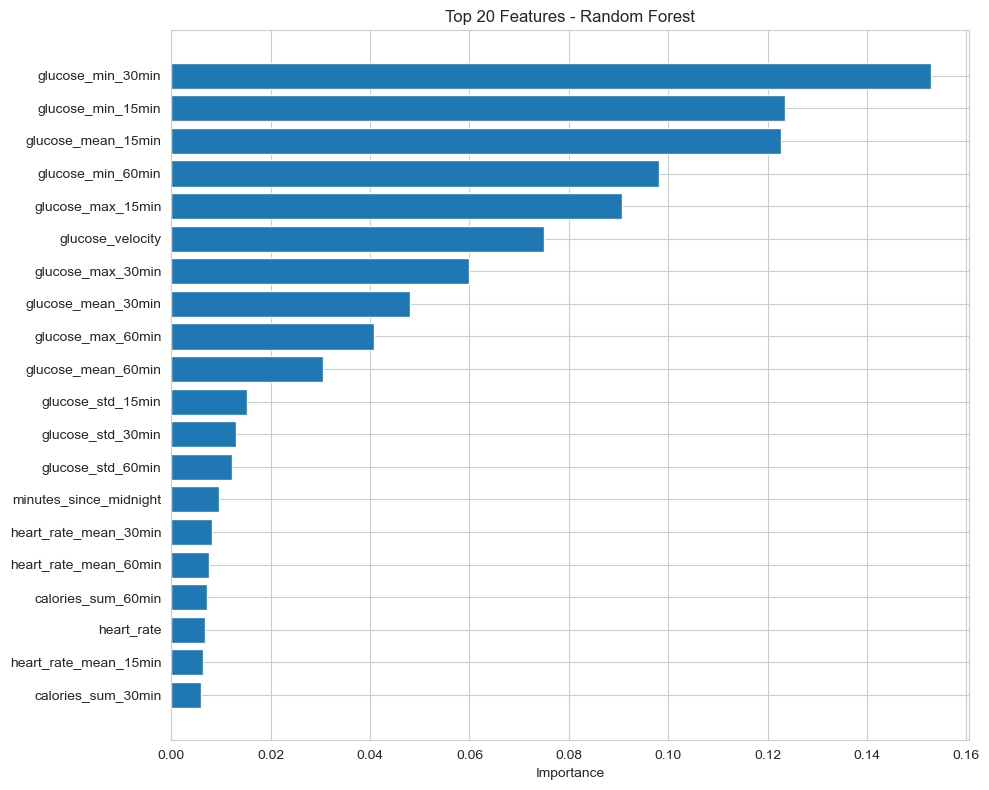

In [31]:
if hasattr(rf_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 8))
    top_20 = importance_df.head(20)
    plt.barh(range(20), top_20['importance'])
    plt.yticks(range(20), top_20['feature'])
    plt.xlabel('Importance')
    plt.title('Top 20 Features - Random Forest')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 7. Model Comparison

In [34]:

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}

if XGBOOST_AVAILABLE and xgb_model is not None:
    models['XGBoost'] = xgb_model

if LIGHTGBM_AVAILABLE and lgb_model is not None:
    models['LightGBM'] = lgb_model

# Evaluate all models
results = []

for name, model in models.items():
    y_pred_val = model.predict(X_val_scaled)
    y_proba_val = model.predict_proba(X_val_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred_val),
        'Precision': precision_score(y_val, y_pred_val),
        'Recall': recall_score(y_val, y_pred_val),
        'F1-Score': f1_score(y_val, y_pred_val),
        'ROC-AUC': roc_auc_score(y_val, y_proba_val)
    })

results_df = pd.DataFrame(results).round(4)

print("MODEL COMPARISON (Validation Set)")
print(results_df.to_string(index=False))

# Select best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1-Score']:.4f}")

MODEL COMPARISON (Validation Set)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9023     0.3683  0.9439    0.5299   0.9699
      Random Forest    0.9542     0.5852  0.7385    0.6530   0.9692
            XGBoost    0.9230     0.4255  0.9168    0.5812   0.9746
           LightGBM    0.9297     0.4487  0.8997    0.5987   0.9720

Best Model: Random Forest
   F1-Score: 0.6530


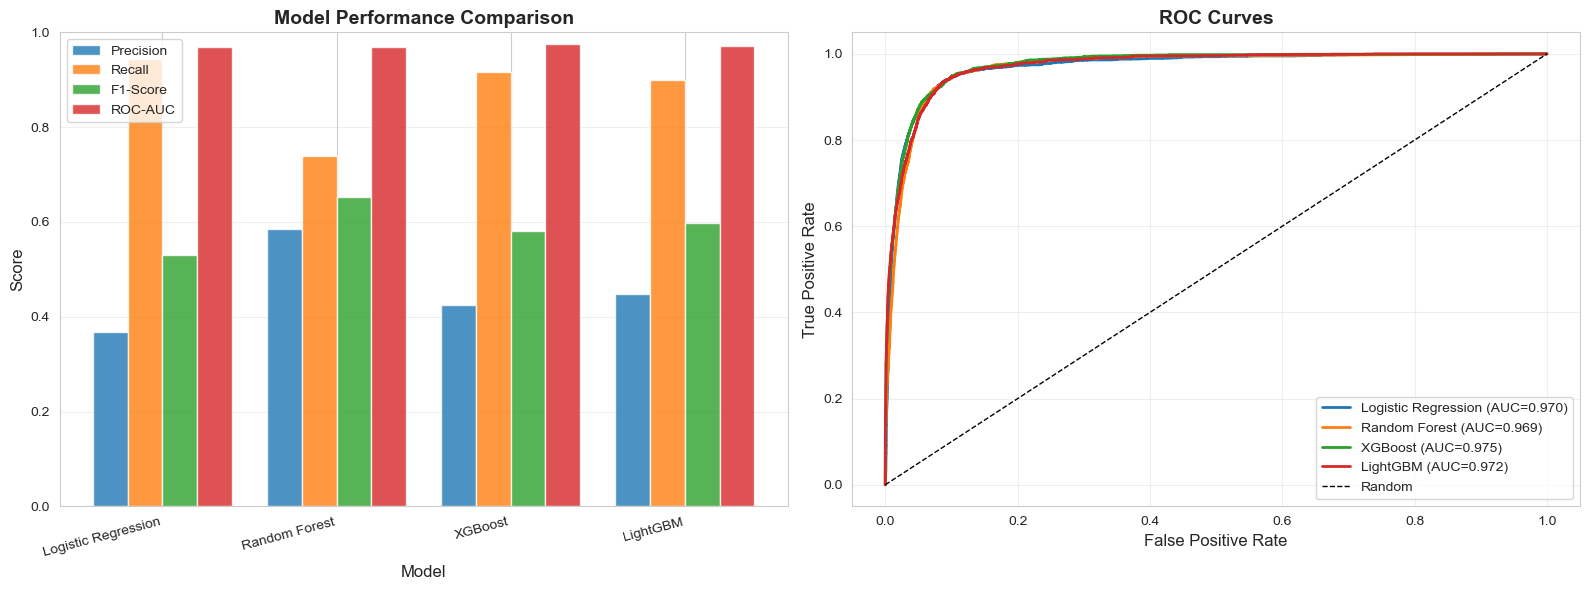

Saved: model_comparison.png


In [35]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Model comparison
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    axes[0].bar(x + i*width, values, width, label=metric, alpha=0.8)

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontweight='bold', fontsize=14)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# ROC curves
for name, model in models.items():
    y_proba = model.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves', fontweight='bold', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIRECTORY}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: model_comparison.png")

In [36]:
import pickle
import warnings
from datetime import datetime
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (make_scorer, recall_score, precision_score, 
                             f1_score, accuracy_score, roc_auc_score, confusion_matrix)

In [38]:

recall_scorer = make_scorer(recall_score)


lr_params = {
    'C': [0.1, 1.0, 10.0],  # Reduced from 6 to 3 options
    'class_weight': [{0: 1, 1: 10}, {0: 1, 1: 15}, {0: 1, 1: 20}]  # Only best weights
}

lr_fast = RandomizedSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, solver='saga'),
    lr_params,
    n_iter=10,  # Only 10 iterations instead of 50!
    cv=3,  # Only 3 folds instead of 5!
    scoring=recall_scorer,
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=0
)

lr_fast.fit(X_train_scaled, y_train)
lr_best = lr_fast.best_estimator_

y_val_pred_lr = lr_best.predict(X_val_scaled)
y_val_proba_lr = lr_best.predict_proba(X_val_scaled)[:, 1]

print(f"Recall: {recall_score(y_val, y_val_pred_lr):.3f}")


rf_params = {
    'n_estimators': [100, 200],  # Reduced options
    'max_depth': [10, 15, 20],  # Reduced options
    'min_samples_split': [5, 10],  # Reduced options
    'class_weight': [{0: 1, 1: 15}, 'balanced']  # Only best weights
}

rf_fast = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=10,  # Only 10 iterations
    cv=3,  # Only 3 folds
    scoring=recall_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_fast.fit(X_train_scaled, y_train)
rf_best = rf_fast.best_estimator_

y_val_pred_rf = rf_best.predict(X_val_scaled)
y_val_proba_rf = rf_best.predict_proba(X_val_scaled)[:, 1]

print(f" Recall: {recall_score(y_val, y_val_pred_rf):.3f}")

if XGBOOST_AVAILABLE:
    
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'scale_pos_weight': [10, 15, 20]
    }
    
    xgb_fast = RandomizedSearchCV(
        xgb.XGBClassifier(random_state=42, n_jobs=-1),
        xgb_params,
        n_iter=10,
        cv=3,
        scoring=recall_scorer,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    xgb_fast.fit(X_train_scaled, y_train)
    xgb_best = xgb_fast.best_estimator_
    
    y_val_pred_xgb = xgb_best.predict(X_val_scaled)
    print(f"Recall: {recall_score(y_val, y_val_pred_xgb):.3f}")

if LIGHTGBM_AVAILABLE:
    
    lgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'class_weight': ['balanced', {0: 1, 1: 15}]
    }
    
    lgb_fast = RandomizedSearchCV(
        lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        lgb_params,
        n_iter=10,
        cv=3,
        scoring=recall_scorer,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    lgb_fast.fit(X_train_scaled, y_train)
    lgb_best = lgb_fast.best_estimator_
    
    y_val_pred_lgb = lgb_best.predict(X_val_scaled)
    print(f" Recall: {recall_score(y_val, y_val_pred_lgb):.3f}")

models = {
    'Logistic Regression': (lr_best, y_val_pred_lr, y_val_proba_lr),
    'Random Forest': (rf_best, y_val_pred_rf, y_val_proba_rf)
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = (xgb_best, y_val_pred_xgb, xgb_best.predict_proba(X_val_scaled)[:, 1])

if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = (lgb_best, y_val_pred_lgb, lgb_best.predict_proba(X_val_scaled)[:, 1])

for name, (model, y_pred, y_proba) in models.items():
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)
    print(f"{name:20s} Recall={recall:.3f}  Precision={precision:.3f}  Missed={cm[1,0]:3d}")

# Select best by recall
best_recall = 0
best_model_name = None
for name, (model, y_pred, y_proba) in models.items():
    recall = recall_score(y_val, y_pred)
    if recall > best_recall:
        best_recall = recall
        best_model_name = name
        best_model = model

print(f"\nBest: {best_model_name} (Recall: {best_recall:.1%})")

y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= 0.4).astype(int)

print(f"\nTest Set (threshold=0.4):")
print(f"  Recall:    {recall_score(y_test, y_test_pred):.3f}")
print(f"  Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred):.3f}")


import pickle
from datetime import datetime

with open('final_model_fast.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'features': feature_cols,
        'model_name': best_model_name,
        'threshold': 0.4,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }, f)

print("\nSaved: final_model_fast.pkl")

Recall: 0.961
 Recall: 0.907
Recall: 0.944
 Recall: 0.936
Logistic Regression  Recall=0.961  Precision=0.335  Missed= 89
Random Forest        Recall=0.907  Precision=0.443  Missed=213
XGBoost              Recall=0.944  Precision=0.388  Missed=127
LightGBM             Recall=0.936  Precision=0.403  Missed=145

Best: Logistic Regression (Recall: 96.1%)

Test Set (threshold=0.4):
  Recall:    0.990
  Precision: 0.442
  F1-Score:  0.611

Saved: final_model_fast.pkl


## 8. Final Evaluation on Test Set

In [39]:
print(f"FINAL TEST SET EVALUATION - {best_model_name}")


y_pred_test = best_model.predict(X_test_scaled)
y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Hypoglycemia']))

cm = confusion_matrix(y_test, y_pred_test)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal  Hypo")
print(f"   Actual Normal  {cm[0,0]:6d}  {cm[0,1]:5d}")
print(f"   Actual Hypo    {cm[1,0]:6d}  {cm[1,1]:5d}")

FINAL TEST SET EVALUATION - Logistic Regression

Test Set Performance:
   Accuracy:  0.9252
   Precision: 0.4825
   Recall:    0.9852
   F1-Score:  0.6478
   ROC-AUC:   0.9859

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96     17935
Hypoglycemia       0.48      0.99      0.65      1347

    accuracy                           0.93     19282
   macro avg       0.74      0.95      0.80     19282
weighted avg       0.96      0.93      0.94     19282


Confusion Matrix:
                 Predicted
                 Normal  Hypo
   Actual Normal   16512   1423
   Actual Hypo        20   1327


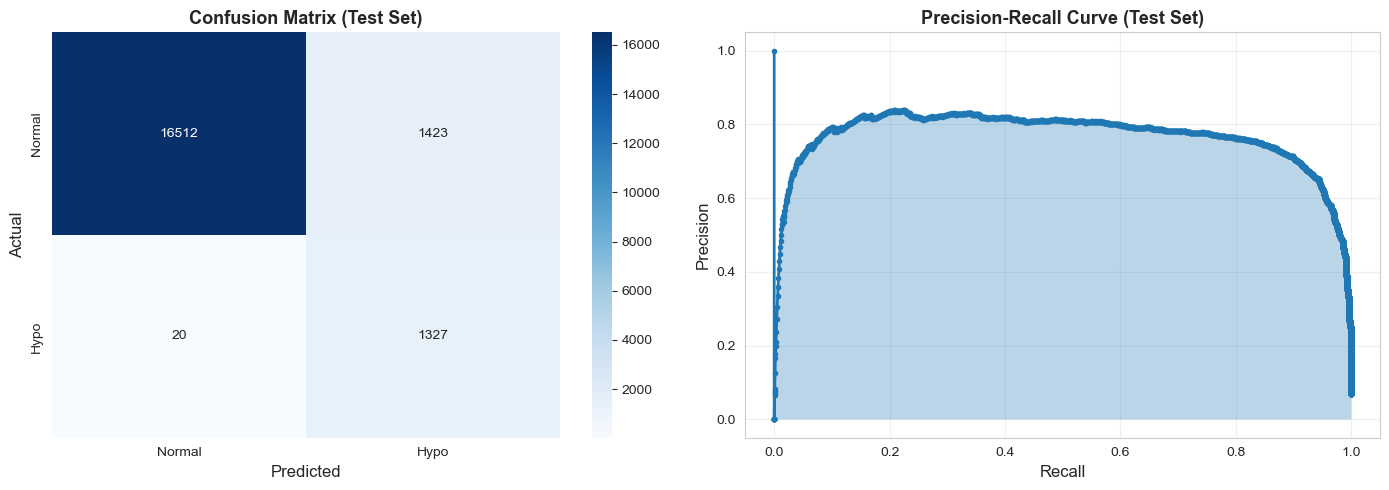


Saved: test_performance.png


In [40]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Hypo'], yticklabels=['Normal', 'Hypo'])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
axes[1].plot(recall, precision, marker='.', linewidth=2)
axes[1].fill_between(recall, precision, alpha=0.3)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve (Test Set)', fontweight='bold', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIRECTORY}/test_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: test_performance.png")

## App Integration

In [42]:
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_columns': feature_cols,
    'model_name': best_model_name,
    'prediction_horizon_minutes': PREDICTION_HORIZON_MINUTES,
    'hypoglycemia_threshold': HYPOGLYCEMIA_THRESHOLD,
    'test_performance': {
        'accuracy': float(accuracy_score(y_test, y_pred_test)),
        'precision': float(precision_score(y_test, y_pred_test)),
        'recall': float(recall_score(y_test, y_pred_test)),
        'f1_score': float(f1_score(y_test, y_pred_test)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_test))
    },
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_cols),
    'n_training_samples': len(X_train),
    'n_training_patients': n_train
}

with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(model_package, f)

print(f"\nSaved to: {MODEL_SAVE_PATH}")
print(f"\n   Model type: {best_model_name}")
print(f"   Features: {len(feature_cols)}")
print(f"   Test F1-Score: {model_package['test_performance']['f1_score']:.4f}")
print(f"   Test Recall: {model_package['test_performance']['recall']:.4f}")
print(f"   Trained on: {n_train} patients")

print(f"\nReady for integration into diabetes management app!")


Saved to: final_model.pkl

   Model type: Logistic Regression
   Features: 44
   Test F1-Score: 0.6478
   Test Recall: 0.9852
   Trained on: 15 patients

Ready for integration into diabetes management app!


## 10. Saved Model

In [ ]:
# Example: Load and test the model
print("TESTING SAVED MODEL")


with open(MODEL_SAVE_PATH, 'rb') as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_scaler = loaded_package['scaler']
loaded_features = loaded_package['feature_columns']

print(f"\nModel loaded successfully")
print(f"   Model: {loaded_package['model_name']}")
print(f"   Trained: {loaded_package['training_date']}")
print(f"   Prediction horizon: {loaded_package['prediction_horizon_minutes']} min")

# Make example prediction
example_data = X_test.iloc[:5]
example_scaled = loaded_scaler.transform(example_data)
predictions = loaded_model.predict(example_scaled)
probabilities = loaded_model.predict_proba(example_scaled)[:, 1]

print(f"\nExample Predictions:")
for i in range(5):
    risk = 'HIGH' if predictions[i] == 1 else 'LOW'
    print(f"   Sample {i+1}: {risk:4s} risk ({probabilities[i]:.1%} probability)")